# The ML Process, Data, and Features

See docs/your-files.md for more information. 


- Author: Denise Case, Kim Hummel 
- Date: 2026-06
- Dataset: Seaborn Penguins
- Target: body_mass_g

Run all cells top to bottom (**Run All**) before pushing to GitHub.

## Overview

This project uses the penguins dataset.
We choose to predict the target `body_mass_g`.
This target is a **numeric** variable (rather than a discrete category), so we have a:

- supervised ML problem (because we've chosen a target)
- a regression problem (because our target is numeric)

Customize the overview in your copy to reflect your dataset and choices.

## Section 1. Project Setup and Imports

In [11]:
# === Section 1a. DECLARE IMPORTS ===

from importlib.metadata import version  # to verify
import logging  # for type hinting
import platform  # to verify
from typing import Final  # for type hinting

from datafun_toolkit.logger import get_logger, log_header
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# === Section 1b. CONFIGURE LOGGER ONCE PER NOTEBOOK ===

LOG: logging.Logger = get_logger("M02", level="DEBUG")
log_header(LOG, "M02")

# === Section 1c. USE THE LOGGER TO VERIFY IMPORTS ===

# If any do NOT return a version number, then that package is not installed correctly.
# Check your pyproject.toml and re-run environment setup commands.

LOG.info("Confirming installation:")
LOG.info(f"  python:       {platform.python_version()}")
LOG.info(f"  pandas:       {version('pandas')}")
LOG.info(f"  numpy:        {version('numpy')}")
LOG.info(f"  scikit-learn: {version('scikit-learn')}")
LOG.info(f"  seaborn:      {version('seaborn')}")
LOG.info(f"  matplotlib:   {version('matplotlib')}")


# === Section 1d. SET PANDAS DISPLAY CONFIGURATION (helps in notebooks) ===

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

2026-07-09 14:01:33 | INFO | M02 | === RUN START ===
2026-07-09 14:01:33 | INFO | M02 | project=M02
2026-07-09 14:01:33 | INFO | M02 | repo_dir=ml-02-features
2026-07-09 14:01:33 | INFO | M02 | python=3.14.3
2026-07-09 14:01:33 | INFO | M02 | os=Windows 11
2026-07-09 14:01:33 | INFO | M02 | shell=powershell
2026-07-09 14:01:33 | INFO | M02 | cwd=notebooks
2026-07-09 14:01:33 | INFO | M02 | github_actions=False
2026-07-09 14:01:33 | INFO | M02 | Confirming installation:
2026-07-09 14:01:33 | INFO | M02 |   python:       3.14.3
2026-07-09 14:01:33 | INFO | M02 |   pandas:       3.0.3
2026-07-09 14:01:33 | INFO | M02 |   numpy:        2.5.1
2026-07-09 14:01:33 | INFO | M02 |   scikit-learn: 1.9.0
2026-07-09 14:01:33 | INFO | M02 |   seaborn:      0.13.2
2026-07-09 14:01:33 | INFO | M02 |   matplotlib:   3.11.0


## Section 2. Load the Data

In [12]:
# === Section 2. Load the Data ===

# We are loading data from Seaborn's built-in datasets,
# which are small datasets included with the Seaborn library
# for practice and demonstration purposes.
# They are listed above with sns.get_dataset_names().
# Experiment with different ones to see what they contain.
# You can also load from CSV files, databases, or APIs and process is similar.

# CUSTOM: In this example, I load a Seaborn dataset by name (no external CSV).
# Change to explore a different dataset.
DATASET_NAME: Final[str] = "penguins"

LOG.info(f"Loading dataset: {DATASET_NAME}")
df: pd.DataFrame = sns.load_dataset(DATASET_NAME)
LOG.info(f"Loaded: {df.shape[0]} rows (instances), {df.shape[1]} columns")

2026-07-09 14:01:33 | INFO | M02 | Loading dataset: penguins
2026-07-09 14:01:33 | INFO | M02 | Loaded: 344 rows (instances), 7 columns


## Section 3. Assess the Data

ANALYST CHOICE: 

Is a  column useful? 
This requires the analyst's judgement.

A column is "useful" only if it carries information about the target AND will be
available at prediction time. 

Code can report completeness and dtype; 
YOU decide which columns to keep, drop, or treat with suspicion.




In [13]:
# === Section 3. Assess the Data ===

# CUSTOM: ANALYST CHOICE - the column you intend to predict.
# Naming it now to watch for features that would leak it.

INTENDED_TARGET: Final[str] = "body_mass_g"
LOG.info(f"The intended target is '{INTENDED_TARGET}'.")
LOG.info("Any feature derived FROM the target would leak the answer. Avoid those.")


# Report facts an analyst needs to judge whether columns are useful.

# WHY: Missingness, type, and basic spread tell us whether a column can
# carry signal and whether it is populated enough to rely on.
# This code reports those facts; it does not decide which columns to keep.

LOG.info("Per-column completeness and type:")

n_rows: int = df.shape[0]

for col in df.columns:
    missing: int = int(df[col].isna().sum())
    pct_present: float = 100.0 * (n_rows - missing) / n_rows
    LOG.info(
        f"  {col:20s} {str(df[col].dtype):10s} present={pct_present:5.1f}%  missing={missing}"
    )

numeric_cols: list[str] = df.select_dtypes(include="number").columns.tolist()
LOG.info("Numeric summary (for spread / outliers):")
LOG.debug(f"\n{df[numeric_cols].describe()}")

2026-07-09 14:01:33 | INFO | M02 | The intended target is 'body_mass_g'.
2026-07-09 14:01:33 | INFO | M02 | Any feature derived FROM the target would leak the answer. Avoid those.
2026-07-09 14:01:33 | INFO | M02 | Per-column completeness and type:
2026-07-09 14:01:33 | INFO | M02 |   species              str        present=100.0%  missing=0
2026-07-09 14:01:33 | INFO | M02 |   island               str        present=100.0%  missing=0
2026-07-09 14:01:33 | INFO | M02 |   bill_length_mm       float64    present= 99.4%  missing=2
2026-07-09 14:01:33 | INFO | M02 |   bill_depth_mm        float64    present= 99.4%  missing=2
2026-07-09 14:01:33 | INFO | M02 |   flipper_length_mm    float64    present= 99.4%  missing=2
2026-07-09 14:01:33 | INFO | M02 |   body_mass_g          float64    present= 99.4%  missing=2
2026-07-09 14:01:33 | INFO | M02 |   sex                  str        present= 96.8%  missing=11
2026-07-09 14:01:33 | INFO | M02 | Numeric summary (for spread / outliers):
2026-07-0

## Section 4. Construct Features

This example builds a size ratio and a size category.

It also creates a feature that makes the gender binary and creats a chart based of size category and gender. 

2026-07-09 14:01:33 | INFO | M02 | Constructing features (vectorized, none are derived from the target)
2026-07-09 14:01:33 | INFO | M02 | Added features: ['bill_ratio', 'flipper_cm', 'size_class', 'sex_binary']
2026-07-09 14:01:33 | DEBUG | M02 | Sample of constructed features:
2026-07-09 14:01:33 | DEBUG | M02 | 
   flipper_length_mm  bill_ratio  flipper_cm size_class  sex_binary
0              181.0    2.090909        18.1      small         0.0
1              186.0    2.270115        18.6      small         1.0
2              195.0    2.238889        19.5     medium         1.0
3                NaN         NaN         NaN        NaN         NaN
4              193.0    1.901554        19.3     medium         1.0


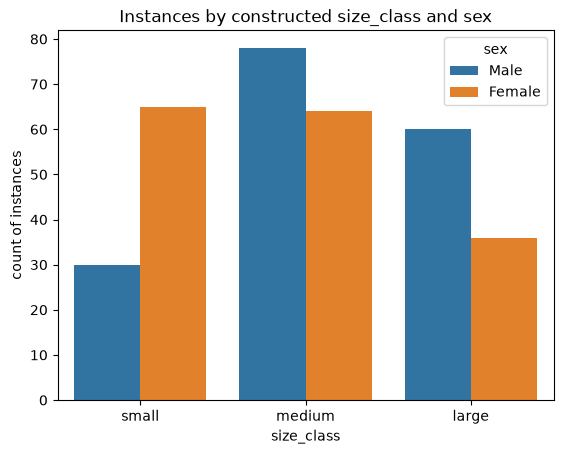

In [14]:
# === Section 4. Construct Features ===

"""Derive new features from existing columns (vectorized).

WHY: New inputs can make a real pattern easier for a model to use.
These operate on whole columns at once (no Python loop).
None of them is built from the intended target, so they cannot leak it.

Built here:
- bill_ratio: bill_length_mm / bill_depth_mm  (shape, unitless)
- flipper_cm: flipper_length_mm / 10            (rescaled)
- size_class: a category from flipper length    (binned)

"""
LOG.info("Constructing features (vectorized, none are derived from the target)")

# Work on a copy so the original stays unchanged.
# Follow current pandas idiom:
# assign explicitly; avoid chained inplace, which silently does nothing
df_feat: pd.DataFrame = df.copy()

df_feat["bill_ratio"] = df_feat["bill_length_mm"] / df_feat["bill_depth_mm"]
df_feat["flipper_cm"] = df_feat["flipper_length_mm"] / 10.0
df_feat["sex_binary"] = df_feat["sex"].map({"Male": 0, "Female": 1})

# A categorical feature via binning. Bins are an ANALYST CHOICE.
df_feat["size_class"] = pd.cut(
    df_feat["flipper_length_mm"],
    bins=[0, 190, 210, np.inf],
    labels=["small", "medium", "large"],
)

new_cols: list[str] = ["bill_ratio", "flipper_cm", "size_class", "sex_binary"]

LOG.info(f"Added features: {new_cols}")

LOG.debug("Sample of constructed features:")
LOG.debug(f"\n{df_feat[['flipper_length_mm', *new_cols]].head()}")

# Show the new categorical feature.
# Visualize in every project.

plt.figure()
sns.countplot(data=df_feat, x="size_class", hue="sex")
plt.title("Instances by constructed size_class and sex")
plt.xlabel("size_class")
plt.ylabel("count of instances")
plt.show()

## Section 5. Summary and Next Steps

First, output key information (may use Python)
Second, provide your narrative, conclusions, and next steps (in Markdown)

In [15]:
# === Python Summary ===


"""Record where we are in the process and the judgment still owed."""
LOG.info("========================")
LOG.info("SUMMARY")
LOG.info("========================")
LOG.info(f"Dataset:          {DATASET_NAME}")
LOG.info(f"Original columns: {df.shape[1]}")
LOG.info(f"After features:   {df_feat.shape[1]}")
LOG.info(f"Intended target:  {INTENDED_TARGET}")
LOG.info("========================")

2026-07-09 14:01:34 | INFO | M02 | ========================
2026-07-09 14:01:34 | INFO | M02 | SUMMARY
2026-07-09 14:01:34 | INFO | M02 | ========================
2026-07-09 14:01:34 | INFO | M02 | Dataset:          penguins
2026-07-09 14:01:34 | INFO | M02 | Original columns: 7
2026-07-09 14:01:34 | INFO | M02 | After features:   11
2026-07-09 14:01:34 | INFO | M02 | Intended target:  body_mass_g
2026-07-09 14:01:34 | INFO | M02 | ========================



### Custom Narrative

This is SUPERVISED learning (because the data includes a target).

The chosen target is `body_mass_g` and that is a continuous numeric variable. 

Therefore, modeling this problem will use **regression**.

### Custom Conclusions

UPDATE THESE REMARKS IN YOUR COPY: 

Which columns are genuinely useful, and which did you distrust? Why?"
The columns stating the bill_length_mm, bill_depth_mm, and flipper_length_mm should be useful as they are also measurements that will hint towards the size or bodies of the penguins. While the gender could potentially be helpful, there are 11 missing values, which is more than any other column which makes me distrust it. 

Which constructed features do you expect to help, and why?"
The bill_ratio should help because it is again helping to describe or give information about the penguins' body which will help us predict the body mass. 

Did you avoid leakage (no feature built from the target)?"
- Yes, I avoided leakage; I did not use 'body_mass_g' to create a new feature. 


## Task: Finalize Your README.md

Include in README.md:

- your project description
- any instructions
- your commands
- a link to key artifacts (including your executed notebook)

When done, you may delete this instruction in your custom notebook.


## Task: Finalize your docs/index.md

In your docs/index.md, include things like:

- Your target.
- Why predicting this target could be useful and for whom.
- Whether ML is a good tool for this problem and why or why not. 
- For example, would a simple rule work better?
- Which features look informative, and which look irrelevant.
- What might 'good enough' mean for this question.

Important:

- There is no threshold that answers these questions automatically.
- Use notebook, README.md, and docs/index.md to share your judgement and your ML skills.


## Task: Final Check

- `README.md` - reflects your description, instructions, commands, and links to your executed notebook.
- `docs/index.md` - reflects your project-specific updates.
- Your GitHub **About** section has a link to your hosted documentation site.
- The executed example notebook AND your custom notebook are available in `notebooks/`.
- Keep this **working example** alongside your custom work until your work has been assessed.
- Ensure your **custom notebook** introduces and narrates **your** custom project.